# Fundamental Quality Score & Random Forest Model
Predict investment outcomes based on company fundamentals

## 1. Data collection and data preprocessing

In [948]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [949]:
# Select company and load data
name = input("Enter the name of the company: ").upper()
df = pd.read_csv(f"../data-companywise/processed_data/{name}.csv")
df

Enter the name of the company:  shl


,date,open,high,low,close,price_change_pct,volume,turnover,year,eps,pe-ratio,roe,dividend,net-margin,pb-ratio,debt-equity
0,2023-01-01,217.0,218.9,213.0,214.0,-1.15,39627,8532327.8,2023,5.37,82.5,23.4,31.5,26.54,18.4,0.08
1,2023-01-02,214.0,216.8,212.2,214.7,0.33,16700,3586554.8,2023,5.37,82.5,23.4,31.5,26.54,18.4,0.08
2,2023-01-03,218.8,227.0,215.2,220.3,2.61,84182,18760003.4,2023,5.37,82.5,23.4,31.5,26.54,18.4,0.08
3,2023-01-04,221.0,223.9,215.3,223.0,1.23,27977,6169118.1,2023,5.37,82.5,23.4,31.5,26.54,18.4,0.08
4,2023-01-05,225.0,234.9,221.0,233.0,4.48,98676,22374873.2,2023,5.37,82.5,23.4,31.5,26.54,18.4,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,2026-03-03,496.0,505.0,495.0,501.8,1.17,19351,9677405.6,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
723,2026-03-09,511.8,532.8,511.8,530.0,5.62,2165,1133000.0,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
724,2026-03-10,530.0,530.0,503.0,515.0,-2.83,138000,71300000.0,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
725,2026-03-11,535.0,539.0,525.0,510.0,-0.97,65828,33700000.0,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [950]:
df

,date,open,high,low,close,price_change_pct,volume,turnover,year,eps,pe-ratio,roe,dividend,net-margin,pb-ratio,debt-equity
0,2023-01-01,217.0,218.9,213.0,214.0,-1.15,39627,8532327.8,2023,5.37,82.5,23.4,31.5,26.54,18.4,0.08
1,2023-01-02,214.0,216.8,212.2,214.7,0.33,16700,3586554.8,2023,5.37,82.5,23.4,31.5,26.54,18.4,0.08
2,2023-01-03,218.8,227.0,215.2,220.3,2.61,84182,18760003.4,2023,5.37,82.5,23.4,31.5,26.54,18.4,0.08
3,2023-01-04,221.0,223.9,215.3,223.0,1.23,27977,6169118.1,2023,5.37,82.5,23.4,31.5,26.54,18.4,0.08
4,2023-01-05,225.0,234.9,221.0,233.0,4.48,98676,22374873.2,2023,5.37,82.5,23.4,31.5,26.54,18.4,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
722,2026-03-03,496.0,505.0,495.0,501.8,1.17,19351,9677405.6,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
723,2026-03-09,511.8,532.8,511.8,530.0,5.62,2165,1133000.0,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
724,2026-03-10,530.0,530.0,503.0,515.0,-2.83,138000,71300000.0,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
725,2026-03-11,535.0,539.0,525.0,510.0,-0.97,65828,33700000.0,2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [951]:
# Check for missing values
df.isna().sum()

date                 0
open                 0
high                 0
low                  0
close                0
price_change_pct     0
volume               0
turnover             0
year                 0
eps                 41
pe-ratio            41
roe                 41
dividend            41
net-margin          41
pb-ratio            41
debt-equity         41
dtype: int64

In [952]:
df.dropna(axis =0, inplace = True)
df

,date,open,high,low,close,price_change_pct,volume,turnover,year,eps,pe-ratio,roe,dividend,net-margin,pb-ratio,debt-equity
0,2023-01-01,217.0,218.9,213.0,214.0,-1.15,39627,8532327.8,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
1,2023-01-02,214.0,216.8,212.2,214.7,0.33,16700,3586554.8,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
2,2023-01-03,218.8,227.0,215.2,220.3,2.61,84182,18760003.4,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
3,2023-01-04,221.0,223.9,215.3,223.0,1.23,27977,6169118.1,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
4,2023-01-05,225.0,234.9,221.0,233.0,4.48,98676,22374873.2,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,2025-12-23,478.0,485.0,471.0,479.5,0.19,15466,7425662.4,2025,6.56,81.7,25.6,31.6,23.81,19.42,0.04
682,2025-12-24,479.5,486.0,475.0,480.5,0.21,11182,5374158.5,2025,6.56,81.7,25.6,31.6,23.81,19.42,0.04
683,2025-12-28,470.9,490.1,470.9,488.5,1.66,12144,5920904.6,2025,6.56,81.7,25.6,31.6,23.81,19.42,0.04
684,2025-12-29,485.0,493.0,480.0,488.1,-0.08,29177,14280950.5,2025,6.56,81.7,25.6,31.6,23.81,19.42,0.04


In [953]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 686 entries, 0 to 685
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              686 non-null    object 
 1   open              686 non-null    float64
 2   high              686 non-null    float64
 3   low               686 non-null    float64
 4   close             686 non-null    float64
 5   price_change_pct  686 non-null    float64
 6   volume            686 non-null    int64  
 7   turnover          686 non-null    float64
 8   year              686 non-null    int64  
 9   eps               686 non-null    float64
 10  pe-ratio          686 non-null    float64
 11  roe               686 non-null    float64
 12  dividend          686 non-null    float64
 13  net-margin        686 non-null    float64
 14  pb-ratio          686 non-null    float64
 15  debt-equity       686 non-null    float64
dtypes: float64(13), int64(2), object(1)
memory usage:

## 2. Data Preprocessing

In [954]:
# Set date as index for time-series analysis
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df

,open,high,low,close,price_change_pct,volume,turnover,year,eps,pe-ratio,roe,dividend,net-margin,pb-ratio,debt-equity
date,,,,,,,,,,,,,,,
2023-01-01,217.0,218.9,213.0,214.0,-1.15,39627,8532327.8,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
2023-01-02,214.0,216.8,212.2,214.7,0.33,16700,3586554.8,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
2023-01-03,218.8,227.0,215.2,220.3,2.61,84182,18760003.4,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
2023-01-04,221.0,223.9,215.3,223.0,1.23,27977,6169118.1,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
2023-01-05,225.0,234.9,221.0,233.0,4.48,98676,22374873.2,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,478.0,485.0,471.0,479.5,0.19,15466,7425662.4,2025,6.56,81.7,25.6,31.6,23.81,19.42,0.04
2025-12-24,479.5,486.0,475.0,480.5,0.21,11182,5374158.5,2025,6.56,81.7,25.6,31.6,23.81,19.42,0.04
2025-12-28,470.9,490.1,470.9,488.5,1.66,12144,5920904.6,2025,6.56,81.7,25.6,31.6,23.81,19.42,0.04


In [955]:
# Sort chronologically
df.sort_index(inplace=True)
df

,open,high,low,close,price_change_pct,volume,turnover,year,eps,pe-ratio,roe,dividend,net-margin,pb-ratio,debt-equity
date,,,,,,,,,,,,,,,
2023-01-01,217.0,218.9,213.0,214.0,-1.15,39627,8532327.8,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
2023-01-02,214.0,216.8,212.2,214.7,0.33,16700,3586554.8,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
2023-01-03,218.8,227.0,215.2,220.3,2.61,84182,18760003.4,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
2023-01-04,221.0,223.9,215.3,223.0,1.23,27977,6169118.1,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
2023-01-05,225.0,234.9,221.0,233.0,4.48,98676,22374873.2,2023,5.37,82.5,23.4,31.5,26.54,18.40,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,478.0,485.0,471.0,479.5,0.19,15466,7425662.4,2025,6.56,81.7,25.6,31.6,23.81,19.42,0.04
2025-12-24,479.5,486.0,475.0,480.5,0.21,11182,5374158.5,2025,6.56,81.7,25.6,31.6,23.81,19.42,0.04
2025-12-28,470.9,490.1,470.9,488.5,1.66,12144,5920904.6,2025,6.56,81.7,25.6,31.6,23.81,19.42,0.04


In [956]:
df.drop(columns = 'pe-ratio', inplace = True)
df

,open,high,low,close,price_change_pct,volume,turnover,year,eps,roe,dividend,net-margin,pb-ratio,debt-equity
date,,,,,,,,,,,,,,
2023-01-01,217.0,218.9,213.0,214.0,-1.15,39627,8532327.8,2023,5.37,23.4,31.5,26.54,18.40,0.08
2023-01-02,214.0,216.8,212.2,214.7,0.33,16700,3586554.8,2023,5.37,23.4,31.5,26.54,18.40,0.08
2023-01-03,218.8,227.0,215.2,220.3,2.61,84182,18760003.4,2023,5.37,23.4,31.5,26.54,18.40,0.08
2023-01-04,221.0,223.9,215.3,223.0,1.23,27977,6169118.1,2023,5.37,23.4,31.5,26.54,18.40,0.08
2023-01-05,225.0,234.9,221.0,233.0,4.48,98676,22374873.2,2023,5.37,23.4,31.5,26.54,18.40,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,478.0,485.0,471.0,479.5,0.19,15466,7425662.4,2025,6.56,25.6,31.6,23.81,19.42,0.04
2025-12-24,479.5,486.0,475.0,480.5,0.21,11182,5374158.5,2025,6.56,25.6,31.6,23.81,19.42,0.04
2025-12-28,470.9,490.1,470.9,488.5,1.66,12144,5920904.6,2025,6.56,25.6,31.6,23.81,19.42,0.04


## 3. Feature Engineering

In [957]:
#Get the first EPS value recorded for each year
annual_eps = df.groupby('year')['eps'].first()

#  Calculate the percentage change between those years
growth_values = annual_eps.pct_change().fillna(0)

#  Turn it into a map and apply it to the whole 'eps_growth' column
growth_map = growth_values.to_dict()
df['eps_growth'] = df['year'].map(growth_map).round(5)


In [958]:
# Inverting the bad metrices which is considered lower as best
df['inv_pb'] = 1/ df['pb-ratio']
df['inv_de'] = df['debt-equity'].apply(lambda x: 1/x if x > 0.01 else 1.0) 

In [959]:
#pe calculated from daily close price and annual EPS
df['pe_dynamic'] = df['close'] / df['eps']
df['inv_pe'] = 1/ df['pe_dynamic']

In [960]:
df['pe_dynamic']

date
2023-01-01    39.851024
2023-01-02    39.981378
2023-01-03    41.024209
2023-01-04    41.527002
2023-01-05    43.389199
                ...    
2025-12-23    73.094512
2025-12-24    73.246951
2025-12-28    74.466463
2025-12-29    74.405488
2025-12-31    75.000000
Name: pe_dynamic, Length: 686, dtype: float64

In [961]:
df.isna().sum()

open                0
high                0
low                 0
close               0
price_change_pct    0
volume              0
turnover            0
year                0
eps                 0
roe                 0
dividend            0
net-margin          0
pb-ratio            0
debt-equity         0
eps_growth          0
inv_pb              0
inv_de              0
pe_dynamic          0
inv_pe              0
dtype: int64

In [962]:
#scaling using minmaxscaler from 0 - 1
df_known =   df.copy()

cols = ['roe', 'net-margin', 'eps_growth','inv_pe','inv_pb','dividend', 'inv_de']
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_known[cols]), columns = cols, index = df_known.index)
df_scaled

,roe,net-margin,eps_growth,inv_pe,inv_pb,dividend,inv_de
date,,,,,,,
2023-01-01,0.0000,1.0,0.000000,1.000000,1.000000,0.000000,0.0
2023-01-02,0.0000,1.0,0.000000,0.994459,1.000000,0.000000,0.0
2023-01-03,0.0000,1.0,0.000000,0.951397,1.000000,0.000000,0.0
2023-01-04,0.0000,1.0,0.000000,0.931407,1.000000,0.000000,0.0
2023-01-05,0.0000,1.0,0.000000,0.861408,1.000000,0.000000,0.0
...,...,...,...,...,...,...,...
2025-12-23,0.6875,0.0,0.067907,0.227031,0.508192,0.018868,1.0
2025-12-24,0.6875,0.0,0.067907,0.225102,0.508192,0.018868,1.0
2025-12-28,0.6875,0.0,0.067907,0.209959,0.508192,0.018868,1.0


In [963]:
df['inv_pe']

date
2023-01-01    0.025093
2023-01-02    0.025012
2023-01-03    0.024376
2023-01-04    0.024081
2023-01-05    0.023047
                ...   
2025-12-23    0.013681
2025-12-24    0.013652
2025-12-28    0.013429
2025-12-29    0.013440
2025-12-31    0.013333
Name: inv_pe, Length: 686, dtype: float64

## 4. Quality score Calculation

In [964]:
# Grouping into the categories
profitability = ['roe', 'net-margin', 'eps_growth']
valuation = ['inv_pe', 'inv_pb'] 
safety = ['dividend', 'inv_de']
df_known['quality_score'] = (
    df_scaled[profitability].mean(axis=1) * 0.50 + 
    df_scaled[valuation].mean(axis=1) * 0.30 + 
    df_scaled[safety].mean(axis=1) * 0.20
).round(4)



In [965]:
df_known['quality_score'].head(5)

date
2023-01-01    0.4667
2023-01-02    0.4658
2023-01-03    0.4594
2023-01-04    0.4564
2023-01-05    0.4459
Name: quality_score, dtype: float64

## 5. Visualizing the Quality score Trend

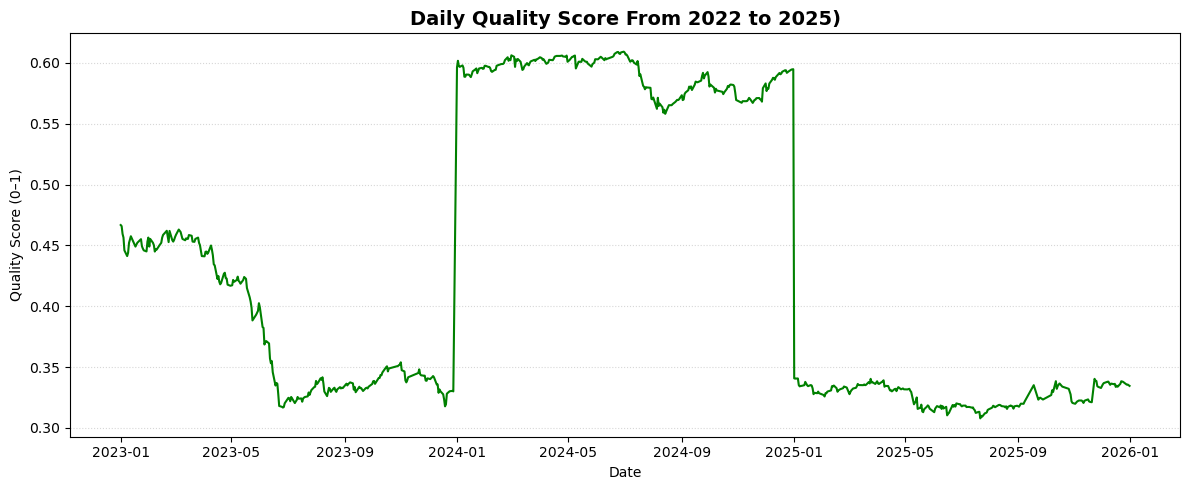

In [966]:
plt.figure(figsize=(12, 5))
plt.plot(df_known.index, df_known['quality_score'], color='green', linewidth=1.5)
plt.title('Daily Quality Score From 2022 to 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Quality Score (0–1)')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('../results/plots/quality_score_trend.png', dpi=300)
plt.show()

## 6. Random Forest Model Training

In [967]:
from sklearn.ensemble import RandomForestRegressor

### i. Defining the features for the model.

In [968]:
#creating the lag features from past quality score
df_known['qs_lag1'] = df_known['quality_score'].shift(1) #from previous day
df_known['qs_lag2'] = df_known['quality_score'].shift(2)
df_known['qs_lag3'] = df_known['quality_score'].shift(3)

#price momentum
df_known['return_1d']  = df_known['close'].pct_change(1)   
df_known['return_5d']  = df_known['close'].pct_change(5)  
df_known['return_20d'] = df_known['close'].pct_change(20)

#moving average
df_known['ma7']  = df_known['close'].rolling(7).mean()
df_known['ma21'] = df_known['close'].rolling(21).mean()
df_known['ma_ratio'] = df_known['ma7'] / df_known['ma21']

#targetting the next day quality score.
df_known['qs_next'] = df_known['quality_score'].shift(-1)


In [969]:
#dropping nan
print(df_known.isna().sum())

df_model = df_known.dropna(subset=['qs_lag1','qs_lag2','qs_lag3','return_1d',
'return_5d','return_20d','ma_ratio','qs_next'])

open                 0
high                 0
low                  0
close                0
price_change_pct     0
volume               0
turnover             0
year                 0
eps                  0
roe                  0
dividend             0
net-margin           0
pb-ratio             0
debt-equity          0
eps_growth           0
inv_pb               0
inv_de               0
pe_dynamic           0
inv_pe               0
quality_score        0
qs_lag1              1
qs_lag2              2
qs_lag3              3
return_1d            1
return_5d            5
return_20d          20
ma7                  6
ma21                20
ma_ratio            20
qs_next              1
dtype: int64


In [970]:
print(f"Total rows for modelling: {len(df_model)}")
print(df_model[['qs_lag1','qs_lag2','qs_lag3','return_1d',
'return_5d','return_20d','ma_ratio','qs_next']].head())

Total rows for modelling: 665
            qs_lag1  qs_lag2  qs_lag3  return_1d  return_5d  return_20d  \
date                                                                      
2023-02-02   0.4490   0.4564   0.4531  -0.025663  -0.038627    0.046729   
2023-02-05   0.4553   0.4490   0.4564   0.013393  -0.029500    0.057289   
2023-02-06   0.4521   0.4553   0.4490   0.008370   0.012832    0.039038   
2023-02-07   0.4501   0.4521   0.4553   0.022280   0.049327    0.049327   
2023-02-08   0.4449   0.4501   0.4521  -0.008547   0.009134   -0.004292   

            ma_ratio  qs_next  
date                           
2023-02-02  1.007698   0.4521  
2023-02-05  1.002134   0.4501  
2023-02-06  0.996600   0.4449  
2023-02-07  0.993823   0.4469  
2023-02-08  0.995703   0.4465  


### ii. Preparing the training set

In [971]:
features = ['qs_lag1','qs_lag2','qs_lag3','return_1d','return_5d','return_20d','ma_ratio','qs_next']

X_train = df_model.loc['2022':'2024', features]
y_train = df_model.loc['2022':'2024', 'qs_next']

X_test  = df_model.loc['2025', features]
y_test  = df_model.loc['2025', 'qs_next']

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")

Train size: 441
Test size:  224


### iii. Scaling the data using MinMaxscaler and model fitting

In [972]:
scaler_rf = MinMaxScaler()
X_train_scaled = scaler_rf.fit_transform(X_train)
X_test_scaled  = scaler_rf.transform(X_test)   # same scaler, only transform

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


### iv. predicting the outcome

In [973]:
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

actual_dir    = np.sign(np.diff(y_test.values))
predicted_dir = np.sign(np.diff(y_pred))
directional_acc = np.mean(actual_dir == predicted_dir)

print(f"RMSE:{rmse:.4f}")
print(f"R²:{r2:.4f}")
print(f"Directional Accuracy: {directional_acc:.2%}")

RMSE:0.0027
R²:0.9048
Directional Accuracy: 86.55%


### v. Checking for the type of signal

In [974]:
latest_qs = df_known['quality_score'].iloc[-1]

print(f"\nLatest 2026 Quality Score: {latest_qs:.4f}")

if latest_qs >= 0.6:
    print("Signal: BULLISH (Buy)")
elif latest_qs <= 0.4:
    print("Signal: BEARISH (Sell)")
else:
    print("Signal: NEUTRAL (Hold)")


Latest 2026 Quality Score: 0.3345
Signal: BEARISH (Sell)


### vi. Considering the important features.

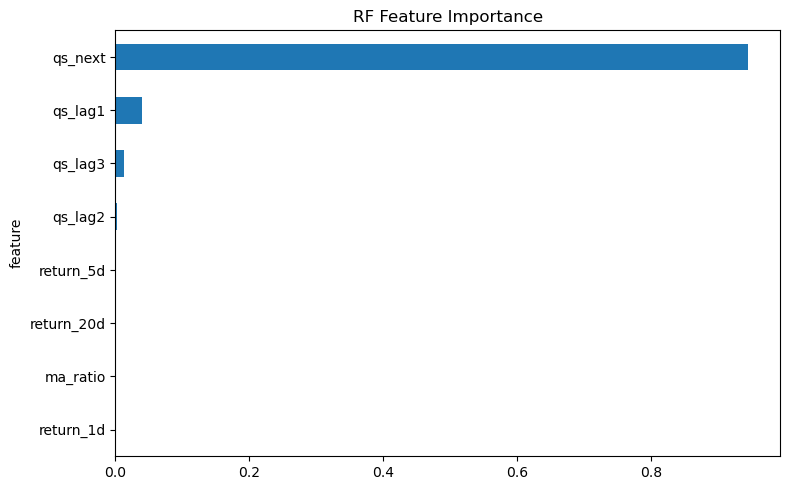

In [975]:
importances = model.feature_importances_
feat_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=True)

feat_df.plot(kind='barh', x='feature', y='importance',
             figsize=(8,5), legend=False,
             title='RF Feature Importance')
plt.tight_layout()
plt.savefig('../results/plots/feature_importance.png', dpi=300)
plt.show()

## 7. Visualizing the result

### Plot 1 — QS Trend with Buy/Sell/Hold Zones

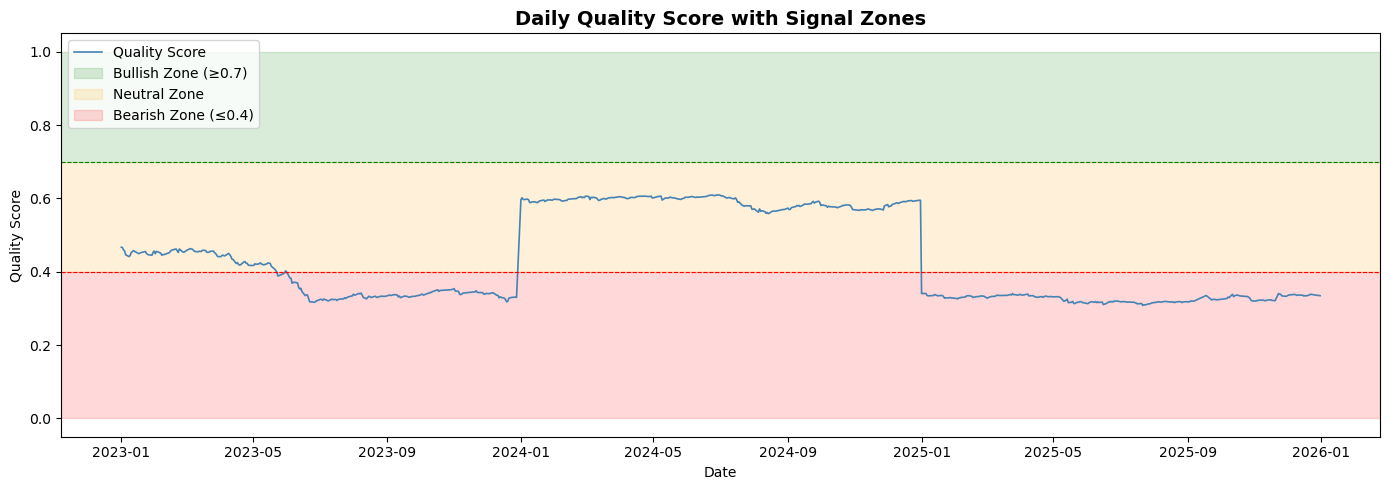

In [976]:
plt.figure(figsize=(14, 5))
plt.plot(df_known.index, df_known['quality_score'], color='steelblue', linewidth=1.2, label='Quality Score')

# Zone bands
plt.axhspan(0.7, 1.0, alpha=0.15, color='green', label='Bullish Zone (≥0.7)')
plt.axhspan(0.4, 0.7, alpha=0.15, color='orange', label='Neutral Zone')
plt.axhspan(0.0, 0.4, alpha=0.15, color='red', label='Bearish Zone (≤0.4)')

plt.axhline(0.7, color='green', linestyle='--', linewidth=0.8)
plt.axhline(0.4, color='red', linestyle='--', linewidth=0.8)

plt.title('Daily Quality Score with Signal Zones', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Quality Score')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../results/plots/qs_zones.png', dpi=300)
plt.show()

### Plot 2 — Correlation Heatmap

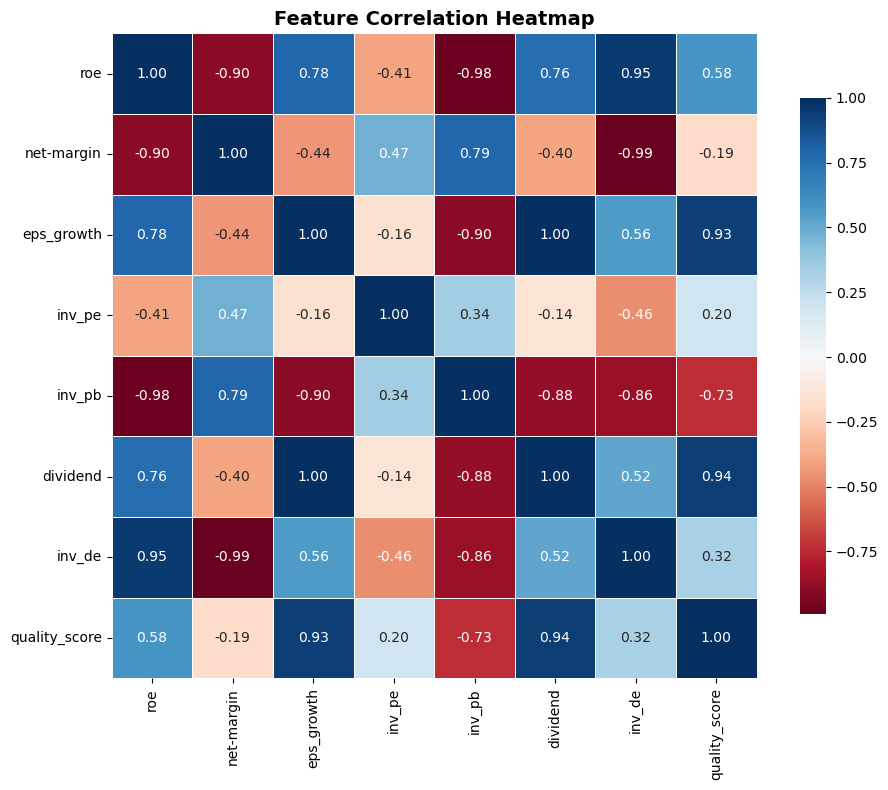

In [977]:
import seaborn as sns

# Features used in QS calculation + quality score itself
corr_cols = [
    'roe', 'net-margin', 'eps_growth','inv_pe', 'inv_pb','dividend', 'inv_de','quality_score'
]

corr_matrix = df_known[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/correlation_heatmap.png', dpi=300)
plt.show()

### Plot 3 — Yearly Average QS (Bar Chart)

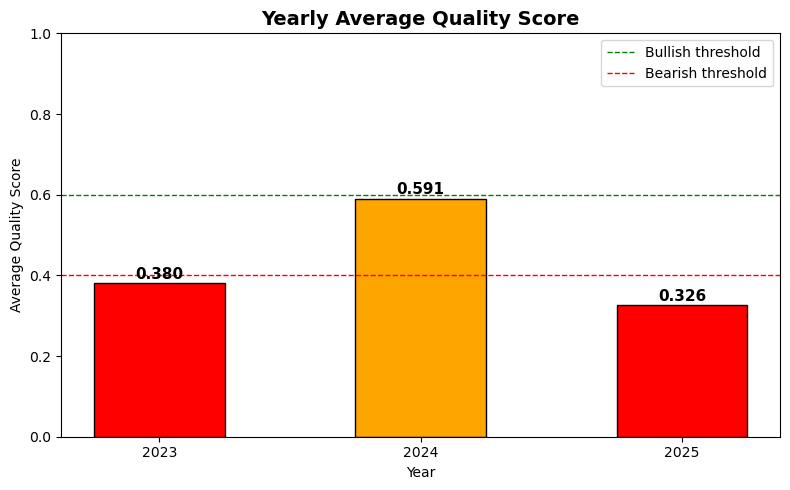

In [978]:
yearly_qs = df_known.groupby('year')['quality_score'].mean()

colors = ['green' if v >= 0.6 else 'red' if v <= 0.4 else 'orange' for v in yearly_qs]

plt.figure(figsize=(8, 5))
bars = plt.bar(yearly_qs.index.astype(str), yearly_qs.values, color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, yearly_qs.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.axhline(0.6, color='green', linestyle='--', linewidth=1, label='Bullish threshold')
plt.axhline(0.4, color='red',   linestyle='--', linewidth=1, label='Bearish threshold')

plt.title('Yearly Average Quality Score', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Quality Score')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/qs_yearly_avg.png', dpi=300)
plt.show()

### Plot 4 — QS Distribution (Histogram)

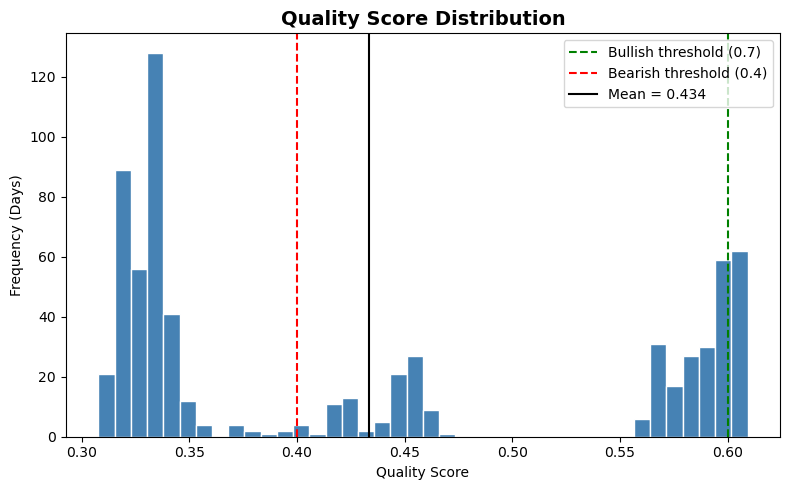

In [979]:
plt.figure(figsize=(8, 5))
plt.hist(df_known['quality_score'], bins=40, color='steelblue', edgecolor='white')

plt.axvline(0.6, color='green', linestyle='--', linewidth=1.5, label='Bullish threshold (0.7)')
plt.axvline(0.4, color='red',   linestyle='--', linewidth=1.5, label='Bearish threshold (0.4)')
plt.axvline(df_known['quality_score'].mean(), color='black',
            linestyle='-', linewidth=1.5, label=f"Mean = {df_known['quality_score'].mean():.3f}")

plt.title('Quality Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score')
plt.ylabel('Frequency (Days)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/plots/qs_distribution.png', dpi=300)
plt.show()

### Plot 5 — Signal Count Per Year (Stacked Bar)

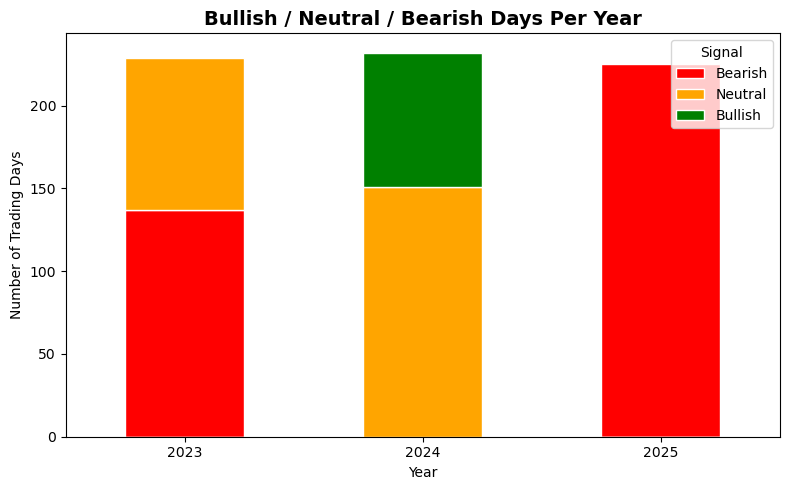

In [980]:
# Add signal column (if not already created)
def classify_qs(score):
    if score >= 0.6:   return 'Bullish'
    elif score <= 0.4: return 'Bearish'
    else:              return 'Neutral'

df_known['signal'] = df_known['quality_score'].apply(classify_qs)

# Now run Plot 6
signal_counts = df_known.groupby(['year', 'signal']).size().unstack(fill_value=0)

# Reorder columns consistently
signal_counts = signal_counts.reindex(columns=['Bearish', 'Neutral', 'Bullish'], fill_value=0)

signal_counts.plot(
    kind='bar', stacked=True, figsize=(8, 5),
    color=['red', 'orange', 'green'],
    edgecolor='white'
)

plt.title('Bullish / Neutral / Bearish Days Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Trading Days')
plt.xticks(rotation=0)
plt.legend(title='Signal')
plt.tight_layout()
plt.savefig('../results/plots/qs_signal_counts.png', dpi=300)
plt.show()

In [981]:
#avg quality score 
avg_scores = df_known['quality_score'].mean().round(2)

In [982]:
import os

avg_score    = round(df_known['quality_score'].mean(), 4)
avg_dividend = round(df['dividend'].mean(), 2)
last_close  = round(df['close'].iloc[-1], 2)
signal       = 'Bullish' if avg_score >= 0.6 else ('Bearish' if avg_score <= 0.4 else 'Neutral')

new_row = pd.DataFrame([{
    'company':      name,
    'avg_score':    avg_score,
    'avg_dividend': avg_dividend,
    'last_close':  last_close,
    'signal':       signal
}])

output_path = '../results/company_scores.csv'

if os.path.exists(output_path):
    existing = pd.read_csv(output_path)
    # Update if company already exists, else append
    existing = existing[existing['company'] != name]
    df_scores = pd.concat([existing, new_row], ignore_index=True)
else:
    df_scores = new_row

df_scores.to_csv(output_path, index=False)
print(f"Saved: {name} | Score: {avg_score} | Signal: {signal} | Last Close Price: {last_close}")

Saved: SHL | Score: 0.4337 | Signal: Neutral | Last Close Price: 492.0
